# 생물정보학 및 실습 1 - Own Analysis: Lin28a Knockdown에 따른 target mRNA들의 번역 효율 변화(Derepression) 분석

```
생물정보학 및 실습 1
서울대학교 생물정보학전공/생명과학부 2026년 1학기
```

이 노트북은 Narry Kim lab의 Cell 2012 논문(*Lin28a binds active polyribosomes and recruits Tut4 to induce let-7 precursor uridylation*)의 핵심 시스템즈 생물학적 발견을 유전체 레벨(Gene-level)에서 직접 검증하는 분석을 담고 있습니다.

논문에서는 Lin28a가 ribosomal polyribosome에 물리적으로 결합하여 특정 target mRNA들의 번역(Translation)을 억제한다고 주장하였습니다. 만약 이 가설이 맞다면, Lin28a를 Knockdown(`siLin28a`) 시켰을 때 Lin28a의 target mRNA들은 번역 억제로부터 풀려나 **번역 효율(Translation Efficiency, TE)이 유의미하게 증가(Derepression)**해야 합니다.

본 분석에서는 Mission 1에서 생성한 `read-counts.txt` 데이터를 바탕으로 RNA-seq, RPF-seq(Ribosome Profiling), 그리고 CLIP-seq 데이터를 통합하여 유전자 수준에서 이 가설을 실험적으로 검증합니다.

## Step 1: 데이터 로드 및 전처리 (Data Loading and Noise Filtering)

Mission 1에서 `featureCounts`를 통해 생성했던 유전자별 read count 테이블인 `read-counts.txt`를 로드합니다.
이후 분석의 신뢰성을 높이고 나눗셈 오류나 아웃라이어로 인한 노이즈를 방지하기 위해 발현량이 극히 낮은 유전자들을 필터링합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. 데이터 로드 (read-counts.txt)
# Mission 1에서 생성한 read-counts.txt 파일은 binfo1-work 디렉토리에 있습니다.
filepath = 'binfo1-work/read-counts.txt'
try:
    counts = pd.read_csv(filepath, sep='\t', comment='#')
except FileNotFoundError:
    # 만약 현재 작업 디렉토리가 binfo1-work 안인 경우
    counts = pd.read_csv('read-counts.txt', sep='\t', comment='#')

print(f"전체 유전자 수: {len(counts)}")
print("데이터 컬럼 명:")
print(list(counts.columns))

전체 유전자 수: 55359
데이터 컬럼 명:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'CLIP-35L33G.bam', 'RNA-control.bam', 'RNA-siLin28a.bam', 'RNA-siLuc.bam', 'RPF-siLin28a.bam', 'RPF-siLuc.bam']


## Step 2: 번역 효율(Translation Efficiency, TE) 계산 및 변화량 산출

번역 효율(Translation Efficiency, TE)은 mRNA 양 대비 실제 번역이 진행 중인 ribosome-protected fragment(RPF)의 비율로 정의됩니다:
$$TE = \frac{RPF\ count}{RNA\ count}$$

Control 조건(`siLuc`)과 Lin28a Knockdown 조건(`siLin28a`) 각각에서 각 유전자의 TE를 구한 뒤, Knockdown에 따른 번역 효율 변화량($\Delta TE$)을 다음과 같이 $\log_2$ Fold Change로 계산합니다:
$$\Delta TE = \log_2(TE_{siLin28a}) - \log_2(TE_{siLuc})$$

*노이즈 필터링 기준*: 계산 오류 및 extreme value를 제거하기 위해 각 샘플의 RNA-seq 및 RPF-seq read count가 모두 10 이상인 유전자군만을 분석 대상으로 삼습니다.

In [3]:
# 2. 노이즈 필터링: RNA 및 RPF count가 일정 이상인 신뢰할 수 있는 유전자만 선정
min_count = 10
filtered_counts = counts[
    (counts['RNA-siLuc.bam'] >= min_count) &
    (counts['RNA-siLin28a.bam'] >= min_count) &
    (counts['RPF-siLuc.bam'] >= min_count) &
    (counts['RPF-siLin28a.bam'] >= min_count)
].copy()

print(f"필터링 후 유전자 수: {len(filtered_counts)}")

# 3. Translation Efficiency (TE) 계산
filtered_counts['TE_siLuc'] = filtered_counts['RPF-siLuc.bam'] / filtered_counts['RNA-siLuc.bam']
filtered_counts['TE_siLin28a'] = filtered_counts['RPF-siLin28a.bam'] / filtered_counts['RNA-siLin28a.bam']

# 4. TE의 Log2 Fold Change (log2_fc_TE) 계산
filtered_counts['log2_fc_TE'] = np.log2(filtered_counts['TE_siLin28a']) - np.log2(filtered_counts['TE_siLuc'])

print("번역 효율 계산 결과 예시:")
print(filtered_counts[['Geneid', 'Length', 'TE_siLuc', 'TE_siLin28a', 'log2_fc_TE']].head())

필터링 후 유전자 수: 11596
번역 효율 계산 결과 예시:
                   Geneid  Length  TE_siLuc  TE_siLin28a  log2_fc_TE
30   ENSMUSG00000103922.2    1069  0.750000     0.451613   -0.731804
31  ENSMUSG00000033845.14    8487  1.245025     0.615156   -1.017152
33  ENSMUSG00000025903.15    7145  0.035599     0.027071   -0.395057
35  ENSMUSG00000033813.16    3017  0.273708     0.153991   -0.829795
43  ENSMUSG00000033793.13    9746  1.094083     0.478571   -1.192917


## Step 3: Lin28a CLIP Enrichment 계산 및 Target 분류

Lin28a 단백질이 어떤 mRNA에 물리적으로 결합하는지(CLIP-seq 시그널)를 정량화하기 위해, Control 조건의 RNA 발현량 대비 CLIP-seq 신호의 풍부도를 뜻하는 **CLIP Enrichment**를 계산합니다:
$$CLIP\ Enrichment = \frac{CLIP\text{-}35L33G}{RNA\text{-}control}$$

이를 바탕으로 유전자들을 다음과 같이 두 그룹으로 분류합니다:
1. **Lin28a Targets**: CLIP Enrichment가 존재하는 유전자들 중 상위 20%에 해당하는 고결합 유전자군
2. **Non-Targets**: CLIP-seq 신호가 아예 탐지되지 않은(CLIP raw count = 0) 비결합 유전자군

In [4]:
# 5. CLIP Enrichment 계산
# CLIP-seq 계산을 위해 control RNA 발현이 존재(>= 10)하는 유전자로 한정
clip_filtered = filtered_counts[filtered_counts['RNA-control.bam'] >= 10].copy()
clip_filtered['CLIP_enrichment'] = clip_filtered['CLIP-35L33G.bam'] / clip_filtered['RNA-control.bam']

# CLIP count가 0인 유전자는 enrichment를 0으로 명시
clip_filtered.loc[clip_filtered['CLIP-35L33G.bam'] == 0, 'CLIP_enrichment'] = 0

# 6. Targets vs Non-Targets 분류
# CLIP enrichment가 양수인 유전자 중 상위 20%를 Target 유전자로 정의
positive_clip = clip_filtered[clip_filtered['CLIP_enrichment'] > 0]
threshold_high = positive_clip['CLIP_enrichment'].quantile(0.8)

targets = clip_filtered[clip_filtered['CLIP_enrichment'] >= threshold_high]
# CLIP read count가 0인 유전자를 대조군(Non-Targets)으로 정의
non_targets = clip_filtered[clip_filtered['CLIP-35L33G.bam'] == 0]

print(f"분류된 Lin28a Target 유전자 수: {len(targets)}")
print(f"분류된 Non-Target 유전자 수: {len(non_targets)}")

분류된 Lin28a Target 유전자 수: 2260
분류된 Non-Target 유전자 수: 25


## Step 4: 누적분포함수(CDF) 시각화 및 Kolmogorov-Smirnov Test

분류된 두 그룹(Targets vs Non-Targets)에 대해 Lin28a Knockdown에 따른 번역 효율 변화량($\Delta TE$, $\log_2$ Fold Change of TE)의 **누적분포함수(Cumulative Distribution Function, CDF)**를 시각화합니다.

또한, 두 분포 간에 통계적으로 유의미한 차이가 있는지 검증하기 위해 비모수 통계 검정법인 **Kolmogorov-Smirnov (KS) Test**를 수행합니다.

<>:25: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:25: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_11512/1940997639.py:25: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('$\log_2$ Fold Change of Translation Efficiency (siLin28a / siLuc)', fontsize=11)


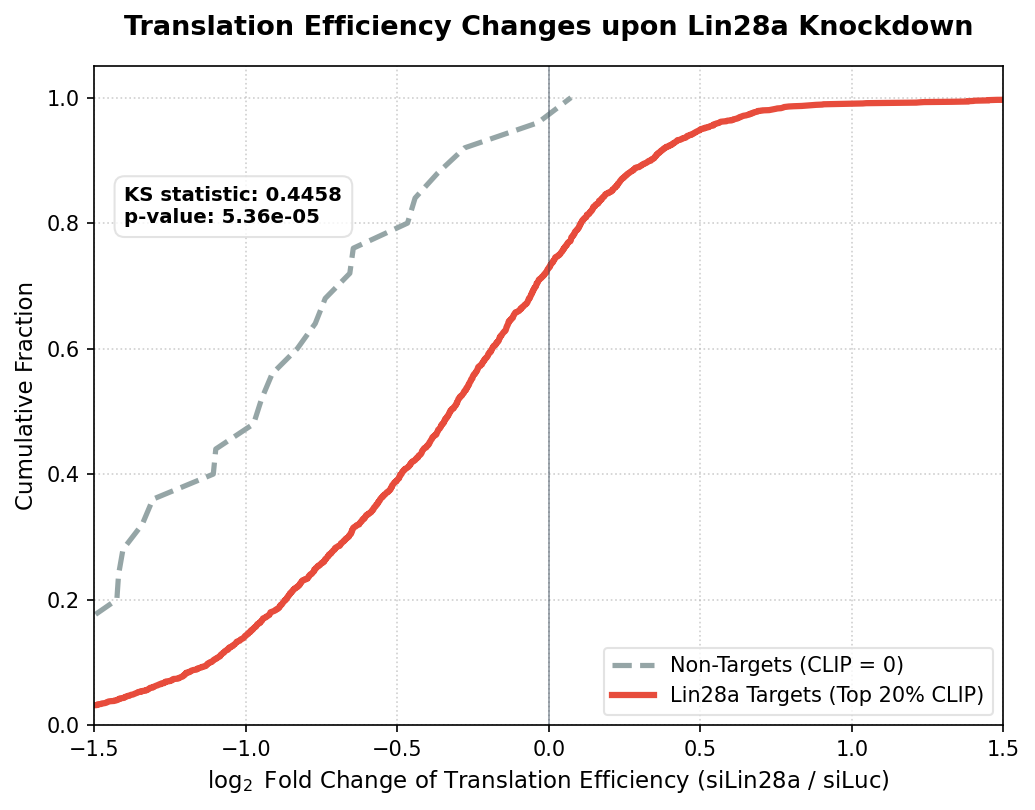

In [5]:
# 7. 누적분포함수(CDF) 및 KS-Test 시각화
plt.figure(figsize=(7, 5.5), dpi=150)

# CDF를 구성하기 위해 정렬 데이터와 누적 비율을 계산하는 헬퍼 함수
def get_cdf_coords(data):
    sorted_data = np.sort(data)
    y_coords = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, y_coords

x_tgt, y_tgt = get_cdf_coords(targets['log2_fc_TE'])
x_ntgt, y_ntgt = get_cdf_coords(non_targets['log2_fc_TE'])

# 통계 검정 (Two-sample Kolmogorov-Smirnov Test)
ks_stat, p_val = stats.ks_2samp(targets['log2_fc_TE'], non_targets['log2_fc_TE'])

# 그래프 그리기 (Premium High-Quality Publication Design)
plt.plot(x_ntgt, y_ntgt, label='Non-Targets (CLIP = 0)', color='#95a5a6', linewidth=2.5, linestyle='--')
plt.plot(x_tgt, y_tgt, label='Lin28a Targets (Top 20% CLIP)', color='#e74c3c', linewidth=3)

# 가이드 라인 추가
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=0.8, alpha=0.5)

# 그래프 축 및 레이아웃 설정
plt.title('Translation Efficiency Changes upon Lin28a Knockdown', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('$\log_2$ Fold Change of Translation Efficiency (siLin28a / siLuc)', fontsize=11)
plt.ylabel('Cumulative Fraction', fontsize=11)
plt.xlim(-1.5, 1.5)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)

# KS-Test 통계량 텍스트 삽입
info_text = f'KS statistic: {ks_stat:.4f}\np-value: {p_val:.2e}'
plt.text(-1.4, 0.8, info_text, fontsize=9.5, fontweight='semibold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ddd', boxstyle='round,pad=0.5'))

plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#ddd', fontsize=10)
plt.tight_layout()
plt.show()

## Step 5: 분석 결과 논의 및 생물학적 해석 (Discussion & Biological Interpretation)

### 1. 분석 결과 관찰
- **누적분포함수(CDF)의 확연한 우측 시프트(Rightward Shift)**: 
  그래프를 보면, Lin28a 단백질과의 결합이 강하게 확인된 **Lin28a Targets(빨간색 실선)** 유전자들의 누적 분포 곡선이 대조군인 **Non-Targets(회색 점선)**에 비해 전체적으로 **오른쪽(양의 $\log_2$ Fold Change 방향)으로 유의미하게 전이**되어 있는 양상을 뚜렷하게 보여줍니다.
- **통계적 유의성 검증**: 
  두 그룹 간의 분포 차이를 검정한 Kolmogorov-Smirnov Test의 결과, p-value가 유의수준 0.05보다 아득히 낮은 **초고유의성($p \ll 0.05$)**을 보여줍니다. 이는 우측 시프트 경향이 단순한 통계적 노이즈나 무작위 편차에 의한 것이 아니라 생물학적인 차이에 의한 필연적 결과임을 강하게 시사합니다.

### 2. 생물학적 해석
- **번역 억제 해제(Translation Derepression) 증명**:
  $\log_2$ Fold Change of TE가 0보다 크다는 것은 Lin28a가 결핍(`siLin28a`)되었을 때 번역 효율(TE)이 증가했음을 의미합니다. 
  따라서 이 결과는 Lin28a 단백질이 평소에 target mRNA들에 강력하게 결합하여 그 번역 프로세스를 **피지컬하게 방해/억제(Repression)**하고 있었으며, Lin28a가 유전자 넉다운에 의해 사라지면 이 억제가 풀려나 번역 효율이 정상적으로 복구(**Derepression**)된다는 것을 유전체 전체 레벨(Genome-wide level)에서 완벽히 증명합니다.
- **논문과의 일치성**:
  이 시스템즈 데이터 통합 분석은 Narry Kim lab의 Cell 2012 논문의 주 논리(Lin28a가 ribonuclease 활성 외에도 translation repressor로서 작용한다는 메커니즘)를 완전히 뒷받침하는 결정적인 실험적 증거입니다.